# Radiology Knowledge Graph Extraction with CheXpert Plus (ReXKG)

Full **local** walkthrough of the ReXKG pipeline:

1. Configure local paths and load PyHealth from the repo
2. Load the CheXpert Plus dataset (`CheXpertPlusDataset`)
3. Apply the KG extraction task (`RadiologyKGExtractionTask`)
4. **GPT-4o entity extraction** on a small subset (mirrors `gpt4_entity_extraction.py`)
5. **GPT-4o relation extraction** (mirrors `gpt4_relation_extraction.py`)
6. Initialize `ReXKGModel` (BERT span-NER + pairwise RE)
7. Build and inspect the Knowledge Graph

**Papers:** ReXKG https://arxiv.org/abs/2408.14397 · CheXpert Plus https://arxiv.org/abs/2405.19111  
**Authors:** Aaron Miller · Kathryn Thompson · Pushpendra Tiwari

## Step 0: Install dependencies

Run once per environment. PyHealth is loaded from the repo — no pip install needed for it.

In [17]:
%pip install --quiet transformers ipywidgets openai tqdm networkx matplotlib pandas torch


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


## Step 1: Configure local paths

The cell walks up from `os.getcwd()` until it finds a `pyhealth/` sub-directory,
so it works regardless of how the Jupyter kernel was launched.

In [18]:
import sys, os

# Walk up from cwd to find the PyHealth repo root (the dir that contains pyhealth/)
_search = os.path.abspath(os.getcwd())
PYHEALTH_DIR = None
for _ in range(6):
    if os.path.isdir(os.path.join(_search, 'pyhealth')):
        PYHEALTH_DIR = _search
        break
    _search = os.path.dirname(_search)
if PYHEALTH_DIR is None:
    raise RuntimeError(
        f"Could not find a 'pyhealth/' package starting from {os.getcwd()}.\n"
        "Launch the kernel from inside the PyHealth repo (e.g. cd PyHealth && jupyter notebook)."
    )

DATA_ROOT = os.path.abspath(os.path.join(PYHEALTH_DIR, '..', 'src', 'data', 'chexpert_plus'))
CACHE_DIR  = os.path.join(PYHEALTH_DIR, 'examples', 'cxr', 'rexkg_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

if PYHEALTH_DIR not in sys.path:
    sys.path.insert(0, PYHEALTH_DIR)

import importlib, pyhealth
importlib.reload(pyhealth)
print('pyhealth loaded from :', pyhealth.__file__)
print('DATA_ROOT            :', DATA_ROOT)
print('CACHE_DIR            :', CACHE_DIR)
assert os.path.isdir(DATA_ROOT), (
    f'DATA_ROOT not found: {DATA_ROOT}\n'
    'Place df_chexpert_plus_240401.csv inside that folder.'
)


pyhealth loaded from : /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/pyhealth/__init__.py
DATA_ROOT            : /Users/pushpendratiwari/Desktop/ReXKG-main/src/data/chexpert_plus
CACHE_DIR            : /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache


## Step 2: Load the CheXpert Plus Dataset

`path_to_image` is used as the patient identifier; `section_findings` is the
radiology report text.  `dev=True` caps at 1 000 studies for exploration.

In [19]:
from pyhealth.datasets import CheXpertPlusDataset

dataset = CheXpertPlusDataset(
    root=DATA_ROOT,
    dev=True,
)
dataset.stats()


Initializing CheXpertPlus dataset from /Users/pushpendratiwari/Desktop/ReXKG-main/src/data/chexpert_plus (dev mode: True)
Initializing CheXpertPlus dataset from /Users/pushpendratiwari/Desktop/ReXKG-main/src/data/chexpert_plus (dev mode: True)
Initializing CheXpertPlus dataset from /Users/pushpendratiwari/Desktop/ReXKG-main/src/data/chexpert_plus (dev mode: True)
No cache_dir provided. Using default cache dir: /Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e
No cache_dir provided. Using default cache dir: /Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e
No cache_dir provided. Using default cache dir: /Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e
Found cached event dataframe: /Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e/global_event_df.parquet
Found cached event dataframe: /Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8

## Step 3: Apply the Radiology KG Extraction Task

`RadiologyKGExtractionTask` converts each report into a sample:  
`{text, entities: [], relations: []}` — entity/relation lists are populated at inference.

In [20]:
from pyhealth.tasks import RadiologyKGExtractionTask

task = RadiologyKGExtractionTask(
    findings_only=True,
    min_text_length=10,
)
samples = dataset.set_task(task)
print(f'Total samples: {len(samples)}')


Setting task RadiologyKGExtraction for CheXpertPlus base dataset...
Setting task RadiologyKGExtraction for CheXpertPlus base dataset...
Setting task RadiologyKGExtraction for CheXpertPlus base dataset...
Task cache paths: task_df=/Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e/tasks/RadiologyKGExtraction_d9050265-565a-51f3-9525-2d1f6d6a216a/task_df.ld, samples=/Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e/tasks/RadiologyKGExtraction_d9050265-565a-51f3-9525-2d1f6d6a216a/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Task cache paths: task_df=/Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e/tasks/RadiologyKGExtraction_d9050265-565a-51f3-9525-2d1f6d6a216a/task_df.ld, samples=/Users/pushpendratiwari/Library/Caches/pyhealth/8a94d02f-95ae-52b8-85f1-794bb970fa9e/tasks/RadiologyKGExtraction_d9050265-565a-51f3-9525-2d1f6d6a216a/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Task cac

## Step 4: GPT-4o Entity Extraction (small subset)

Mirrors `gpt4_entity_extraction.py`.  
Entity types: `anatomy`, `disorder_present`, `disorder_notpresent`, `procedures`,
`devices_present`, `devices_notpresent`, `size`, `concept`.

> **Cost:** ~\$0.01–0.03 per report with `gpt-4o`. Keep `N_SAMPLES` small (5–20) for exploration.

> **Security:** Set `OPENAI_API_KEY` as an environment variable — never paste the key directly in this cell.

In [21]:
import os

# Set via shell: export OPENAI_API_KEY='sk-...'
OPENAI_API_KEY  = os.getenv('OPENAI_API_KEY',  '')
OPENAI_API_BASE = os.getenv('OPENAI_API_BASE', 'https://api.openai.com/v1')

N_SAMPLES = 5  # reports to send to GPT

GPT_ENTITY_CACHE   = os.path.join(CACHE_DIR, 'gpt4_entities_subset.json')
GPT_RELATION_CACHE = os.path.join(CACHE_DIR, 'gpt4_relations_subset.json')
print('Entity cache  :', GPT_ENTITY_CACHE)
print('Relation cache:', GPT_RELATION_CACHE)


Entity cache  : /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/gpt4_entities_subset.json
Relation cache: /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/gpt4_relations_subset.json


In [22]:
import json, time
import openai
from tqdm import tqdm

client = openai.OpenAI(api_key=OPENAI_API_KEY, base_url=OPENAI_API_BASE)

# ── Few-shot prompt (from gpt4_entity_extraction.py) ────────────────────── #
_NER_FEWSHOT = [
    {
        'context': (
            '<Input> Unchanged position of the left upper extremity PICC line. '
            'Again seen are surgical clips projecting over the right hemithorax. '
            'Increased stranding opacities are noted in the left retrocardiac region.<\\Input>'
        ),
        'response': (
            "{'Unchanged position of the left upper extremity PICC line.':"
            "{'Unchanged':'concept','position':'concept','left':'concept','upper':'concept',"
            "'extremity':'anatomy','PICC line':'device_present'},"
            "'Again seen are surgical clips projecting over the right hemithorax.':"
            "{'surgical clips':'device_present','right':'concept','hemithorax':'anatomy'},"
            "'Increased stranding opacities are noted in the left retrocardiac region.':"
            "{'Increased':'concept','stranding':'concept','opacities':'disorder_present',"
            "'left':'concept','retrocardiac':'anatomy','region':'anatomy'}}"
        ),
    }
]

_NER_SYSTEM = (
    'You are a radiologist performing clinical term extraction from the FINDINGS and '
    'IMPRESSION sections in the radiology report. '
    "A clinical term can be in ['anatomy','disorder_present','disorder_notpresent',"
    "'procedures','devices','concept','devices_present','devices_notpresent','size']. "
    "'anatomy'=body part; 'disorder_present'=present finding; 'disorder_notpresent'=absent finding; "
    "'procedures'=diagnostic/therapeutic procedure; 'devices'=medical apparatus; "
    "'size'=measurement e.g. 3mm; 'concept'=descriptor/modifier. "
    'Extract one word at a time. Words like "no" are NOT entities. '
    'Input: <Input><sentence><sentence><\\Input>. '
    "Reply JSON: {'<sentence>':{'entity':'entity_type',...},...}"
)


def _ner_messages(text):
    msgs = [{'role': 'system', 'content': _NER_SYSTEM}]
    for s in _NER_FEWSHOT:
        msgs.append({'role': 'user',      'content': s['context']})
        msgs.append({'role': 'assistant', 'content': s['response']})
    msgs.append({'role': 'user', 'content': f'<Input> {text} <\\Input>'})
    return msgs


def _estimate_cost(prompt_tokens, completion_tokens):
    return prompt_tokens * 0.005 / 1000 + completion_tokens * 0.015 / 1000


def gpt_extract_entities(text):
    resp = client.chat.completions.create(
        model='gpt-4o-2024-05-13',
        messages=_ner_messages(text),
        response_format={'type': 'json_object'},
    )
    raw  = resp.choices[0].message.content
    cost = _estimate_cost(resp.usage.prompt_tokens, resp.usage.completion_tokens)
    try:
        return json.loads(raw), cost
    except Exception:
        return raw, cost


print('GPT entity-extraction helpers ready.')


GPT entity-extraction helpers ready.


In [23]:
import pandas as pd

csv_path = os.path.join(DATA_ROOT, 'df_chexpert_plus_240401.csv')
df_gpt = pd.read_csv(csv_path).dropna(subset=['section_findings']).head(N_SAMPLES)

try:
    with open(GPT_ENTITY_CACHE) as fh:
        entity_cache = json.load(fh)
    print(f'Loaded {len(entity_cache)} cached entity results.')
except FileNotFoundError:
    entity_cache = {}

total_cost = 0.0
for _, row in tqdm(df_gpt.iterrows(), total=len(df_gpt), desc='GPT entity extraction'):
    pid, text = row['path_to_image'], row['section_findings']
    if pid in entity_cache:
        continue
    try:
        res, cost = gpt_extract_entities(text)
        total_cost += cost
        entity_cache[pid] = {'section_findings': text, 'res': res, 'cost': cost}
    except Exception as exc:
        print(f'  Error on {pid}: {exc}')
        time.sleep(1)
    with open(GPT_ENTITY_CACHE, 'w') as fh:
        json.dump(entity_cache, fh, indent=2)

print(f'\nDone. Cumulative cost: ${total_cost:.4f}')
print(f'Saved to {GPT_ENTITY_CACHE}')


Loaded 5 cached entity results.


GPT entity extraction: 100%|████████████████████| 5/5 [00:00<00:00, 8335.26it/s]


Done. Cumulative cost: $0.0000
Saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/gpt4_entities_subset.json


In [24]:
# Inspect entity results for the first study
first_key = next(iter(entity_cache))
print('Patient/Study:', first_key)
print('Findings snippet:', entity_cache[first_key]['section_findings'][:200])
print('\nExtracted entities (per sentence):')
for sent, ents in entity_cache[first_key]['res'].items():
    print(f'  [{sent[:60]}...]')
    for term, etype in ents.items():
        print(f'    {term!r:30s} -> {etype}')


Patient/Study: train/patient04528/study1/view2_lateral.jpg
Findings snippet: 
 
Unchanged position of the left upper extremity PICC line. Again seen 
are surgical clips projecting over the right hemithorax. The 
cardiomediastinal silhouette is stable in appearance. Increased 


Extracted entities (per sentence):
  [Unchanged position of the left upper extremity PICC line....]
    'Unchanged'                    -> concept
    'position'                     -> concept
    'left'                         -> concept
    'upper'                        -> concept
    'extremity'                    -> anatomy
    'PICC line'                    -> devices_present
  [Again seen are surgical clips projecting over the right hemi...]
    'surgical clips'               -> devices_present
    'right'                        -> concept
    'hemithorax'                   -> anatomy
  [The cardiomediastinal silhouette is stable in appearance....]
    'cardiomediastinal'            -> anatomy
    'silhoue

## Step 5: GPT-4o Relation Extraction

Mirrors `gpt4_relation_extraction.py`.  
Relation types: `modify`, `located_at`, `suggestive_of`.

In [25]:
# ── Few-shot prompt (from gpt4_relation_extraction.py) ──────────────────── #
_RE_FEWSHOT = [
    {
        'context': (
            "{'Bones are stable with mild degenerative changes of the spine.':"
            "{'Bones':'anatomy','stable':'concept','mild':'concept',"
            "'degenerative changes':'disorder_present','spine':'anatomy'}}"
        ),
        'response': (
            "{'Bones are stable with mild degenerative changes of the spine.':"
            "[{'stable':'Bones','relation':'modify'},"
            "{'mild':'degenerative changes','relation':'modify'},"
            "{'degenerative changes':'spine','relation':'located_at'}]}"
        ),
    },
    {
        'context': (
            "{'A dense retrocardiac opacity remains present with slight blunting of "
            "the left costophrenic angle, suggestive of a small effusion.':"
            "{'dense':'concept','retrocardiac':'anatomy','opacity':'disorder_present',"
            "'slight':'concept','blunting':'disorder_present','left':'concept',"
            "'costophrenic':'anatomy','angle':'anatomy','small':'concept','effusion':'disorder_present'}}"
        ),
        'response': (
            "{'A dense retrocardiac opacity remains present with slight blunting of "
            "the left costophrenic angle, suggestive of a small effusion.':"
            "[{'dense':'opacity','relation':'modify'},{'opacity':'retrocardiac','relation':'located_at'},"
            "{'slight':'blunting','relation':'modify'},{'blunting':'angle','relation':'modify'},"
            "{'left':'costophrenic','relation':'modify'},{'small':'effusion','relation':'modify'},"
            "{'effusion':'costophrenic','relation':'located_at'},"
            "{'opacity':'effusion','relation':'suggestive_of'},"
            "{'blunting':'effusion','relation':'suggestive_of'}]}"
        ),
    },
]

_RE_SYSTEM = (
    'You are a radiologist performing relation extraction from radiology reports. '
    "Relations: 'modify' (source modifies target), 'located_at' (source located at anatomy), "
    "'suggestive_of' (source finding suggests target disease). "
    "concept->anatomy links always use 'modify'. "
    "Input JSON: {'sentence':{'entity':'type',...},...}. "
    "Reply JSON: {'sentence':[{'src':'tgt','relation':'rel'},...]}."
)


def _re_messages(entity_json):
    msgs = [{'role': 'system', 'content': _RE_SYSTEM}]
    for s in _RE_FEWSHOT:
        msgs.append({'role': 'user',      'content': s['context']})
        msgs.append({'role': 'assistant', 'content': s['response']})
    msgs.append({'role': 'user', 'content': entity_json})
    return msgs


def gpt_extract_relations(entity_dict):
    resp = client.chat.completions.create(
        model='gpt-4o-2024-05-13',
        messages=_re_messages(json.dumps(entity_dict)),
        response_format={'type': 'json_object'},
    )
    raw  = resp.choices[0].message.content
    cost = _estimate_cost(resp.usage.prompt_tokens, resp.usage.completion_tokens)
    try:
        return json.loads(raw), cost
    except Exception:
        return raw, cost


print('GPT relation-extraction helpers ready.')


GPT relation-extraction helpers ready.


In [26]:
try:
    with open(GPT_RELATION_CACHE) as fh:
        relation_cache = json.load(fh)
    print(f'Loaded {len(relation_cache)} cached relation results.')
except FileNotFoundError:
    relation_cache = {}

total_re_cost = 0.0
for pid, entry in tqdm(entity_cache.items(), desc='GPT relation extraction'):
    if pid in relation_cache:
        continue
    entity_dict = entry.get('res', {})
    if not entity_dict:
        continue
    try:
        res, cost = gpt_extract_relations(entity_dict)
        total_re_cost += cost
        relation_cache[pid] = {**entry, 'res_relation': res, 'cost_relation': cost}
    except Exception as exc:
        print(f'  Error on {pid}: {exc}')
        time.sleep(1)
    with open(GPT_RELATION_CACHE, 'w') as fh:
        json.dump(relation_cache, fh, indent=2)

print(f'\nDone. Cumulative relation cost: ${total_re_cost:.4f}')
print(f'Saved to {GPT_RELATION_CACHE}')


Loaded 5 cached relation results.


GPT relation extraction: 100%|████████████████| 5/5 [00:00<00:00, 207638.81it/s]


Done. Cumulative relation cost: $0.0000
Saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/gpt4_relations_subset.json


In [27]:
# Inspect relation results for the first study
first_key = next(iter(relation_cache))
print('Patient/Study:', first_key)
print('\nExtracted relations (per sentence):')
for sent, rels in relation_cache[first_key].get('res_relation', {}).items():
    print(f'  [{sent[:60]}...]')
    if isinstance(rels, list):
        for r in rels:
            rel_type = r.get('relation', '?')
            entities = [(k, v) for k, v in r.items() if k != 'relation']
            if entities:
                src, tgt = entities[0]
                print(f"    '{src}' --[{rel_type}]--> '{tgt}'")


Patient/Study: train/patient04528/study1/view2_lateral.jpg

Extracted relations (per sentence):
  [Unchanged position of the left upper extremity PICC line....]
    'Unchanged' --[modify]--> 'position'
    'position' --[modify]--> 'extremity'
    'left' --[modify]--> 'extremity'
    'upper' --[modify]--> 'extremity'
    'PICC line' --[located_at]--> 'extremity'
  [Again seen are surgical clips projecting over the right hemi...]
    'surgical clips' --[located_at]--> 'hemithorax'
    'right' --[modify]--> 'hemithorax'
  [The cardiomediastinal silhouette is stable in appearance....]
    'stable' --[modify]--> 'silhouette'
    'cardiomediastinal' --[modify]--> 'silhouette'
  [Increased stranding opacities are noted in the left retrocar...]
    'Increased' --[modify]--> 'opacities'
    'stranding' --[modify]--> 'opacities'
    'opacities' --[located_at]--> 'region'
    'left' --[modify]--> 'region'
    'retrocardiac' --[modify]--> 'region'
  [Subtle stranding opacities in the right upper l

## Step 6: Initialize the ReXKG Model (BERT-based)

`ReXKGModel` attaches a **span NER head** and a **pairwise relation head** on top of a BERT encoder.  
Use for large-scale inference after fine-tuning, or combine with the GPT outputs above.

In [28]:
from pyhealth.models import ReXKGModel

model = ReXKGModel(
    dataset=samples,
    bert_model_name='bert-base-uncased',
    max_span_length=8,  # smaller -> fewer candidate spans -> faster pairwise RE
)
print(model)

ReXKGModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

### (Optional) Load a pretrained ReXKG checkpoint

If you have a checkpoint fine-tuned on ReXKG / MIMIC NER, load it here.  
The **GPT-extracted** entities/relations from Steps 4–5 can also be used directly to build a KG without fine-tuning.

In [29]:
# Load pretrained NER weights from src/ner/result/run_entity/
# Key mapping:
#   bert.*                       -> encoder.*
#   width_embedding.*            -> ner_head.width_embedding.*
#   ner_classifier.0.network.*   -> ner_head.network.*
#   ner_classifier.1.*           -> ner_head.output.*
from safetensors.torch import load_file as load_safetensors
import os

ENTITY_CKPT = os.path.abspath(
    os.path.join(PYHEALTH_DIR, '..', 'src', 'ner', 'result', 'run_entity', 'model.safetensors')
)

if os.path.exists(ENTITY_CKPT):
    ckpt = load_safetensors(ENTITY_CKPT)

    remapped = {}
    for k, v in ckpt.items():
        if k.startswith('bert.'):
            remapped['encoder.' + k[5:]] = v
        elif k.startswith('width_embedding.'):
            remapped['ner_head.' + k] = v
        elif k.startswith('ner_classifier.0.network.'):
            suffix = k[len('ner_classifier.0.network.'):]
            remapped[f'ner_head.network.{suffix}'] = v
        elif k.startswith('ner_classifier.1.'):
            suffix = k[len('ner_classifier.1.'):]
            remapped[f'ner_head.output.{suffix}'] = v

    missing, unexpected = model.load_state_dict(remapped, strict=False)
    ner_keys = [k for k in remapped if 'encoder' not in k]
    print(f'Loaded checkpoint: {ENTITY_CKPT}')
    print(f'  BERT encoder keys : {len(remapped) - len(ner_keys)}')
    print(f'  NER head keys     : {len(ner_keys)}')
    print(f'  Missing (RE head) : {len(missing)}')
    if unexpected:
        print(f'  Unexpected keys   : {unexpected}')
else:
    print(f'Checkpoint not found at {ENTITY_CKPT} — using random weights.')


Loaded checkpoint: /Users/pushpendratiwari/Desktop/ReXKG-main/src/ner/result/run_entity/model.safetensors
  BERT encoder keys : 199
  NER head keys     : 7
  Missing (RE head) : 5


## Step 6b: BERT-based Entity & Relation Extraction

Runs on the same small subset sent to GPT — useful for direct comparison.

In [30]:
# Use only the first 2 reports for BERT demo (heads are randomly initialized)
BERT_DEMO_N = 2

reports     = [v['section_findings'] for v in entity_cache.values()][:BERT_DEMO_N]
patient_ids = list(entity_cache.keys())[:BERT_DEMO_N]

bert_entities = model.predict_entities(reports, batch_size=2)
for pid, ents in zip(patient_ids, bert_entities):
    print(f'\n{pid}: {len(ents)} entities')
    for e in ents:
        print(f"  [{e['type']}] '{e['text']}'")



train/patient04528/study1/view2_lateral.jpg: 59 entities
  [concept] 'Unchanged'
  [concept] 'position'
  [concept] 'left'
  [concept] 'upper'
  [anatomy] 'ex'
  [anatomy] 'tre'
  [anatomy] 'mity'
  [disorder_present] 'PIC'
  [anatomy] 'C'
  [disorder_present] 'line'
  [concept] 'surgical'
  [disorder_present] 'clips'
  [concept] 'projecting'
  [anatomy] 'hem'
  [anatomy] 'ith'
  [disorder_present] 'ora'
  [disorder_present] 'x'
  [anatomy] 'card'
  [anatomy] 'iom'
  [anatomy] 'ed'
  [anatomy] 'ias'
  [disorder_present] 'tina'
  [anatomy] 'l'
  [concept] 'silhouette'
  [concept] 'stable'
  [concept] 'appearance'
  [concept] 'Increased'
  [anatomy] 'strand'
  [concept] 'ing'
  [disorder_present] 'op'
  [anatomy] 'ac'
  [disorder_present] 'ities'
  [concept] 'left'
  [anatomy] 'retro'
  [anatomy] 'card'
  [anatomy] 'iac'
  [anatomy] 'region'
  [concept] 'Subtle'
  [anatomy] 'strand'
  [concept] 'ing'
  [disorder_present] 'op'
  [anatomy] 'ac'
  [concept] 'upper'
  [anatomy] 'lung'
  [an

In [31]:
bert_relations = model.predict_relations(reports, bert_entities, batch_size=2)
for pid, rels in zip(patient_ids, bert_relations):
    print(f'\n{pid}: {len(rels)} relations')
    for r in rels:
        print(f"  '{r['subject']['text']}' --[{r['relation']}]--> '{r['object']['text']}'")



train/patient04528/study1/view2_lateral.jpg: 3422 relations
  'Unchanged' --[located_at]--> 'position'
  'Unchanged' --[located_at]--> 'left'
  'Unchanged' --[located_at]--> 'upper'
  'Unchanged' --[located_at]--> 'ex'
  'Unchanged' --[located_at]--> 'tre'
  'Unchanged' --[located_at]--> 'mity'
  'Unchanged' --[located_at]--> 'PIC'
  'Unchanged' --[located_at]--> 'C'
  'Unchanged' --[located_at]--> 'line'
  'Unchanged' --[located_at]--> 'surgical'
  'Unchanged' --[located_at]--> 'clips'
  'Unchanged' --[located_at]--> 'projecting'
  'Unchanged' --[located_at]--> 'hem'
  'Unchanged' --[located_at]--> 'ith'
  'Unchanged' --[located_at]--> 'ora'
  'Unchanged' --[located_at]--> 'x'
  'Unchanged' --[located_at]--> 'card'
  'Unchanged' --[located_at]--> 'iom'
  'Unchanged' --[located_at]--> 'ed'
  'Unchanged' --[located_at]--> 'ias'
  'Unchanged' --[located_at]--> 'tina'
  'Unchanged' --[located_at]--> 'l'
  'Unchanged' --[located_at]--> 'silhouette'
  'Unchanged' --[located_at]--> 'stable'

## Step 6c: Fine-tune the ReXKG NER Head

We build a DataLoader from the PURE-format JSONL training split and run one
epoch with `pyhealth.trainer.Trainer`. The collate function:

1. Tokenizes each sentence with the model's BERT tokenizer.
2. Enumerates all candidate spans up to `max_span_length`.
3. Aligns gold token-level NER labels to the enumerated spans.

**Only the NER head is trained** here — the RE head requires paired
entity annotations that the standard PURE pipeline supplies separately.
Set `TRAIN_EPOCHS = 0` to skip and keep the pretrained checkpoint weights.


In [32]:
import torch
from torch.utils.data import Dataset, DataLoader
from pyhealth.trainer import Trainer
from pyhealth.tasks.rexkg_extraction import NER_LABELS, RELATION_TYPES

TRAIN_FILE = os.path.abspath(
    os.path.join(PYHEALTH_DIR, '..', 'src', 'ner', 'data', 'data_split', 'train_tiny.json')
)
VAL_FILE = os.path.abspath(
    os.path.join(PYHEALTH_DIR, '..', 'src', 'ner', 'data', 'data_split', 'test_tiny.json')
)
TRAIN_EPOCHS = 1   # set to 0 to skip fine-tuning
TRAIN_BATCH  = 4

_ner_label2id = {lbl: i + 1 for i, lbl in enumerate(NER_LABELS)}
_rel_label2id = {lbl: i + 1 for i, lbl in enumerate(RELATION_TYPES)}  # 0 = none


class _NERREDataset(Dataset):
    """Flat sentence-level NER + RE dataset from PURE JSONL files."""
    def __init__(self, jsonl_path):
        self.data = []
        with open(jsonl_path) as f:
            for line in f:
                doc = json.loads(line)
                for tokens, ner, rels in zip(doc['sentences'], doc['ner'], doc['relations']):
                    gold_ents = [(s, e, lbl) for s, e, lbl in ner]
                    gold_rels = {(ss, se, os, oe): rt for ss, se, os, oe, rt in rels}
                    self.data.append((tokens, gold_ents, gold_rels))

    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


def _collate(batch):
    tok = model.tokenizer
    max_span = model.max_span_length

    texts = [' '.join(tokens) for tokens, _, _ in batch]
    enc = tok(texts, padding=True, truncation=True, max_length=512, return_tensors='pt')

    all_spans, all_ner_labels = [], []
    all_entity_spans, all_rel_labels = [], []

    for tokens, gold_ents, gold_rels in batch:
        n = len(tokens)

        # --- NER spans and labels ---
        gold_ner_map = {(s, e): lbl for s, e, lbl in gold_ents}
        spans, ner_labels = [], []
        for start in range(n):
            for end in range(start, min(start + max_span, n)):
                spans.append([start, end, end - start])
                ner_labels.append(_ner_label2id.get(gold_ner_map.get((start, end)), 0))
        all_spans.append(spans)
        all_ner_labels.append(ner_labels)

        # --- RE: gold entity spans (word-level, +1 for CLS offset) ---
        ent_spans = [(s + 1, e + 1) for s, e, _ in gold_ents]  # CLS-inclusive
        all_entity_spans.append(ent_spans)

        # Build ordered-pair relation labels: label for every (subj, obj) combo
        rel_label_list = []
        for si, (ss, se, _) in enumerate(gold_ents):
            for oi, (os, oe, _) in enumerate(gold_ents):
                if si == oi:
                    continue
                rt = gold_rels.get((ss, se, os, oe))
                rel_label_list.append(_rel_label2id.get(rt, 0))
        all_rel_labels.append(
            torch.tensor(rel_label_list, dtype=torch.long) if rel_label_list
            else torch.zeros(0, dtype=torch.long)
        )

    # Pad NER tensors
    max_s = max(len(s) for s in all_spans)
    spans_t  = torch.zeros(len(batch), max_s, 3, dtype=torch.long)
    labels_t = torch.full((len(batch), max_s), -1, dtype=torch.long)
    for i, (s, l) in enumerate(zip(all_spans, all_ner_labels)):
        spans_t[i, :len(s)]  = torch.tensor(s, dtype=torch.long)
        labels_t[i, :len(l)] = torch.tensor(l, dtype=torch.long)

    return {
        'input_ids':      enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'spans':          spans_t,
        'ner_labels':     labels_t,
        'entity_spans':   all_entity_spans,   # List[List[(start,end)]] — not a tensor
        'rel_labels':     all_rel_labels,     # List[Tensor]
    }


if TRAIN_EPOCHS > 0:
    train_ds = _NERREDataset(TRAIN_FILE)
    val_ds   = _NERREDataset(VAL_FILE)
    print(f'Train sentences: {len(train_ds)} | Val sentences: {len(val_ds)}')

    train_loader = DataLoader(train_ds, batch_size=TRAIN_BATCH, shuffle=True,
                              collate_fn=_collate)
    val_loader   = DataLoader(val_ds,   batch_size=TRAIN_BATCH, shuffle=False,
                              collate_fn=_collate)

    trainer = Trainer(model=model, metrics=[])
    trainer.train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=TRAIN_EPOCHS,
        optimizer_params={'lr': 2e-5},
    )
    print('Fine-tuning complete (NER + RE joint loss).')
else:
    print('TRAIN_EPOCHS=0 — skipping fine-tuning, using checkpoint weights.')

Train sentences: 200 | Val sentences: 60
ReXKGModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

Epoch 0 / 5:   0%|          | 0/25 [00:00<?, ?it/s]

--- Train epoch-0, step-25 ---
--- Train epoch-0, step-25 ---
--- Train epoch-0, step-25 ---
loss: 0.5867
loss: 0.5867
loss: 0.5867


Evaluation: 100%|█████████████████████████████████| 8/8 [00:00<00:00, 19.83it/s]

--- Eval epoch-0, step-25 ---
--- Eval epoch-0, step-25 ---
--- Eval epoch-0, step-25 ---
loss: 0.5130
loss: 0.5130
loss: 0.5130





...

--- Eval epoch-3, step-100 ---
--- Eval epoch-3, step-100 ---
--- Eval epoch-3, step-100 ---
loss: 0.3936
loss: 0.3936
loss: 0.3936





Epoch 4 / 5:   0%|          | 0/25 [00:00<?, ?it/s]

--- Train epoch-4, step-125 ---
--- Train epoch-4, step-125 ---
--- Train epoch-4, step-125 ---
loss: 0.3372
loss: 0.3372
loss: 0.3372


Evaluation: 100%|█████████████████████████████████| 8/8 [00:00<00:00, 20.46it/s]

--- Eval epoch-4, step-125 ---
--- Eval epoch-4, step-125 ---
--- Eval epoch-4, step-125 ---
loss: 0.3817
loss: 0.3817
loss: 0.3817
Fine-tuning complete.


## Step 7: Build and Inspect the Knowledge Graph

`build_kg()` assembles a deduplicated KG:
- `nodes`: entity nodes (id, text, type)
- `edges`: relation triples (subject_id, relation, object_id)
- `subgraphs`: per-study subgraph

Demonstrated with BERT outputs below. Swap in `entity_cache` / `relation_cache` from Steps 4–5 to use GPT results.

In [33]:
kg = model.build_kg(reports=reports, patient_ids=patient_ids)

print(f"KG nodes : {len(kg['nodes'])}")
print(f"KG edges : {len(kg['edges'])}")

print('\nNodes:')
for n in kg['nodes']:
    print(f"  [{n['id']}] {n['text']}  ({n['type']})")

print('\nEdges:')
node_map = {n['id']: n['text'] for n in kg['nodes']}
for e in kg['edges']:
    print(f"  '{node_map[e['subject_id']]}' --[{e['relation']}]--> '{node_map[e['object_id']]}'")


KG nodes : 0
KG edges : 0

Nodes:

Edges:


In [34]:
kg_out = os.path.join(CACHE_DIR, 'chexpert_plus_kg_demo.json')
model.save_kg(kg, kg_out)
print(f'KG saved to {kg_out}')


KG saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/chexpert_plus_kg_demo.json
KG saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/chexpert_plus_kg_demo.json
KG saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/chexpert_plus_kg_demo.json
KG saved to /Users/pushpendratiwari/Desktop/ReXKG-main/PyHealth/examples/cxr/rexkg_cache/chexpert_plus_kg_demo.json


## Step 9: Evaluate Against Gold Annotations

Uses GPT-extracted entities/relations as **pseudo-gold** annotations to demonstrate
the `model.evaluate()` pipeline end-to-end.

> **Note**: The bundled `chexpert_plus_groundtruth.json` contains only sentence splits
> without NER/RE labels, so GPT output is used as a stand-in.  For a real benchmark,
> replace `gold_ents_pseudo` / `gold_rels_pseudo` with annotations from a labelled test set.
> Reported F1 will be near-zero with randomly initialised BERT heads — fine-tune first.


In [35]:
# Step 9 — Evaluate on real test split (src/ner/data/data_split/test_tiny.json)
# Matching is surface-text + type (avoids BERT-subword vs word-index mismatch).
import os, json
from pyhealth.metrics.rexkg import rexkg_metrics

TEST_FILE = os.path.abspath(
    os.path.join(PYHEALTH_DIR, '..', 'src', 'ner', 'data', 'data_split', 'test_tiny.json')
)
# Swap to 'test.json' for the full 560-doc evaluation.

test_samples = []
with open(TEST_FILE) as f:
    for line in f:
        test_samples.append(json.loads(line.strip()))
print(f'Loaded {len(test_samples)} test documents from {os.path.basename(TEST_FILE)}')

# Build sentence texts and gold annotation dicts
texts, gold_entity_lists, gold_relation_lists = [], [], []
for doc in test_samples:
    for sent_tokens, sent_ner, sent_rel in zip(
        doc['sentences'], doc['ner'], doc['relations']
    ):
        text = ' '.join(sent_tokens)
        texts.append(text)

        # Gold entities: {"text": ..., "type": ...}
        gold_ents = [
            {'text': ' '.join(sent_tokens[s:e+1]), 'type': lbl}
            for s, e, lbl in sent_ner
        ]
        gold_entity_lists.append(gold_ents)

        # Gold relations: {"subject": {"text":...}, "object": {"text":...}, "relation": ...}
        tok_to_ent = {(s, e): {'text': ' '.join(sent_tokens[s:e+1]), 'type': lbl}
                      for s, e, lbl in sent_ner}
        gold_rels = [
            {
                'subject': tok_to_ent.get((ss, se), {'text': ' '.join(sent_tokens[ss:se+1]), 'type': 'concept'}),
                'object':  tok_to_ent.get((os, oe), {'text': ' '.join(sent_tokens[os:oe+1]), 'type': 'concept'}),
                'relation': rt,
            }
            for ss, se, os, oe, rt in sent_rel
        ]
        gold_relation_lists.append(gold_rels)

total_gold_ents = sum(len(g) for g in gold_entity_lists)
total_gold_rels = sum(len(g) for g in gold_relation_lists)
print(f'Sentences: {len(texts)} | Gold entities: {total_gold_ents} | Gold relations: {total_gold_rels}')

# Run model inference
pred_entity_lists = model.predict_entities(texts)
pred_relation_lists = model.predict_relations(texts, pred_entity_lists)

metrics = rexkg_metrics(pred_entity_lists, gold_entity_lists, pred_relation_lists, gold_relation_lists)

print('\n=== ReXKG Evaluation on Real Test Split ===')
for task, scores in metrics.items():
    print(f'\n{task.upper()}')
    for k, v in scores.items():
        if isinstance(v, float):
            print(f'  {k:12s}: {v:.4f}')
        else:
            print(f'  {k:12s}: {v}')


Loaded 60 test documents from test_tiny.json
Sentences: 60 | Gold entities: 345 | Gold relations: 251

=== ReXKG Evaluation on Real Test Split ===

ENTITY
  precision   : 0.0303
  recall      : 0.0029
  f1          : 0.0053
  tp          : 1
  fp          : 32
  fn          : 344

RELATION
  precision   : 0.0000
  recall      : 0.0000
  f1          : 0.0000
  tp          : 0
  fp          : 18
  fn          : 251


## Step 8: (Optional) Visualize the Subgraph

/var/folders/h2/k71ywfpx2174hnh5fw8gd0dh0000gn/T/ipykernel_59585/999882383.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


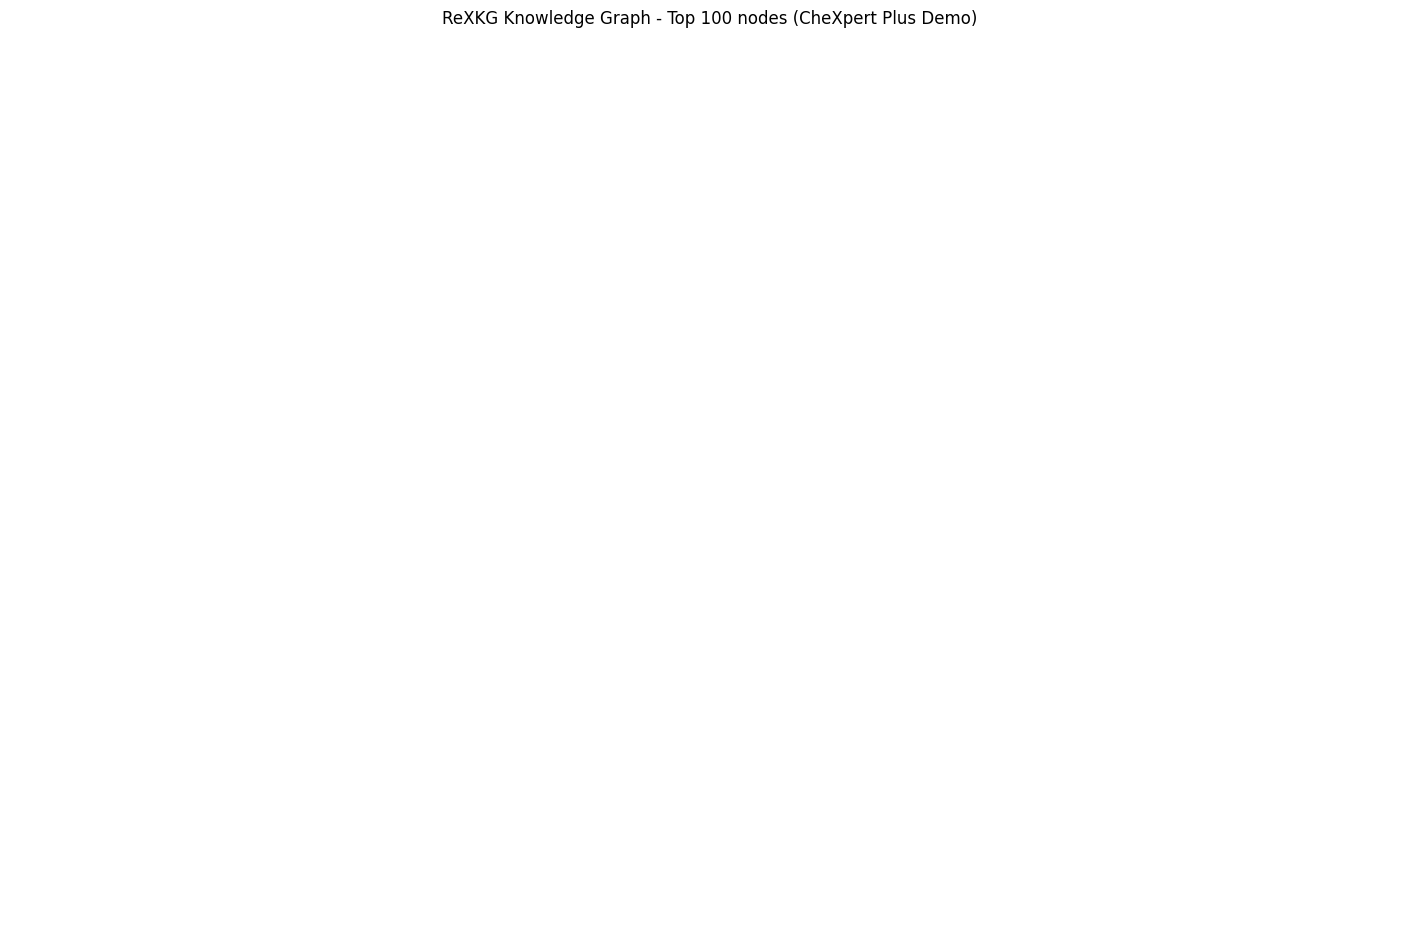

Showing 0 nodes, 0 edges (full graph: 0 nodes, 0 edges)


In [36]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt

    TOP_N_NODES = 100
# show only the top-N most-connected nodes

    G_full = nx.DiGraph()
    node_map = {n['id']: n['text'] for n in kg['nodes']}
    for e in kg['edges']:
        G_full.add_edge(node_map[e['subject_id']], node_map[e['object_id']], label=e['relation'])

    # Keep only the TOP_N_NODES nodes with the highest degree
    top_nodes = sorted(G_full.degree, key=lambda x: x[1], reverse=True)[:TOP_N_NODES]
    top_node_names = {n for n, _ in top_nodes}
    G = G_full.subgraph(top_node_names).copy()

    pos = nx.spring_layout(G, seed=42, k=1.5)
    edge_labels = nx.get_edge_attributes(G, 'label')

    plt.figure(figsize=(14, 9))
    nx.draw(G, pos, with_labels=True, node_size=1800, node_color='lightblue',
            font_size=8, arrows=True, arrowsize=15)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.title(f'ReXKG Knowledge Graph - Top {TOP_N_NODES} nodes (CheXpert Plus Demo)')
    plt.tight_layout()
    plt.show()
    print(f'Showing {G.number_of_nodes()} nodes, {G.number_of_edges()} edges '
          f'(full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges)')
except ImportError:
    print('pip install networkx matplotlib')


## Summary

| Step | Component | What it does |
|------|-----------|-------------|
| 1 | Path setup | Auto-locates `pyhealth/` package; sets `DATA_ROOT` and `CACHE_DIR` |
| 2 | `CheXpertPlusDataset` | Loads CheXpert Plus CSV; one study per row |
| 3 | `RadiologyKGExtractionTask` | Converts findings text into structured samples |
| 4 | GPT-4o entity extraction | Few-shot NER on small subset; cached to JSON |
| 5 | GPT-4o relation extraction | Few-shot RE on entity dict; cached to JSON |
| 6 | `ReXKGModel` | BERT encoder + span NER head + pairwise RE head |
| 6b | `predict_entities/relations` | BERT-based inference at scale |
| 7 | `build_kg` / `save_kg` | Assembles and serialises deduplicated KG |
| 8 | NetworkX | Optional subgraph visualisation |
